In [4]:
import pandas as pd 
import numpy as np

from sklearn.model_selection import  train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [5]:
df = pd.read_csv("../data/day_7.csv")
print(df.shape)
print(df.columns)

(1480, 23)
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Returns',
       'Rolling Mean', 'Rolling Volatility', 'Cumulative Return', 'Fear_Greed',
       'Risk_Adjustment_Returns', 'Fear_Signal', 'Investor_Bias',
       'Recommendataion', 'sharpe_Rato', 'Rolling_Sharpe', 'Performance',
       'Recommendation', 'Strategy_Return', 'Cumulative_Strategy_Return',
       'Cumulative_Market_Return', 'Recommendation_Shifted'],
      dtype='object')


In [6]:
df=df.copy()

df['Momentum'] = df['Close']-df['Close'].shift(5)

df['MA_Short'] = df['Close'].rolling(window=5).mean()
df['MA_Long'] =  df['Close'].rolling(window=20).mean()

df['MA_crossover'] = np.where(df['MA_Short'] > df['MA_Long'],1,0)

df['Volatility_Change'] = df['Rolling Volatility'].pct_change()

df['Prince_Change']=df['Close'].pct_change()




In [7]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Returns',
       'Rolling Mean', 'Rolling Volatility', 'Cumulative Return', 'Fear_Greed',
       'Risk_Adjustment_Returns', 'Fear_Signal', 'Investor_Bias',
       'Recommendataion', 'sharpe_Rato', 'Rolling_Sharpe', 'Performance',
       'Recommendation', 'Strategy_Return', 'Cumulative_Strategy_Return',
       'Cumulative_Market_Return', 'Recommendation_Shifted', 'Momentum',
       'MA_Short', 'MA_Long', 'MA_crossover', 'Volatility_Change',
       'Prince_Change'],
      dtype='object')

In [8]:
df[['Momentum',
       'MA_Short', 'MA_Long', 'MA_crossover', 'Volatility_Change',
       'Prince_Change']].head(10)

,Momentum,MA_Short,MA_Long,MA_crossover,Volatility_Change,Prince_Change
0,NaN,NaN,NaN,0,NaN,NaN
1,NaN,NaN,NaN,0,NaN,-0.002225
2,NaN,NaN,NaN,0,NaN,0.002992
3,NaN,NaN,NaN,0,NaN,0.006435
4,NaN,40.795650,NaN,0,NaN,-0.005639
5,0.517555,40.899162,NaN,0,NaN,0.011166
6,0.908688,41.080899,NaN,0,NaN,0.007284
7,0.810917,41.243082,NaN,0,NaN,0.000574
8,0.677357,41.378554,NaN,0,NaN,0.003098
9,0.498470,41.478248,NaN,0,NaN,-0.009836


In [12]:
df.rename(columns={'Prince_Change':'Price_Change'},inplace=True)

In [13]:
ml_data = df.dropna()

print("Shape Before Cleaning ",df.shape)

print("Shape after cleaning",ml_data.shape)

Shape Before Cleaning  (1480, 29)
Shape after cleaning (1422, 29)


In [14]:
features = ['Momentum',
       'MA_Short', 
       'MA_Long', 
       'MA_crossover',
       'Volatility_Change',
       'Price_Change',
       'Rolling Volatility',
       'Rolling Mean', 
       'Volume']

x = ml_data[features]
y = ml_data['Recommendation_Shifted']


print("x Shape:",x.shape)
print("y Shape:",y.shape)

print("Target values : ",y.unique())

x Shape: (1422, 9)
y Shape: (1422,)
Target values :  ['Sell' 'Hold' 'Buy']


In [15]:
# ==============================
# 1️⃣ Import Libraries
# ==============================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from xgboost import XGBClassifier


# ==============================
# 2️⃣ Train-Test Split
# ==============================

x_train, x_test, y_train, y_test = train_test_split(
    x ,y,                # your features and labels
    test_size=0.2,
    random_state=42,
    stratify=y           # VERY IMPORTANT for imbalance
)


# ==============================
# 3️⃣ Encode Labels
# ==============================

encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded  = encoder.transform(y_test)


# ==============================
# 4️⃣ Build XGBoost Model
# ==============================

model = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=3,
    reg_alpha=0.3,
    reg_lambda=1,
    objective='multi:softprob',   # important
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)


# ==============================
# 5️⃣ Train Model
# ==============================

model.fit(x_train, y_train_encoded)


# ==============================
# 6️⃣ Predict on Test Data
# ==============================

y_pred_encoded = model.predict(x_test)

# Convert back to original labels (Buy, Hold, Sell)
y_pred = encoder.inverse_transform(y_pred_encoded)


# ==============================
# 7️⃣ Evaluation
# ==============================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nPrediction Counts:")
print(pd.Series(y_pred).value_counts())

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8245614035087719

Prediction Counts:
Hold    267
Buy      10
Sell      8
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

         Buy       0.40      0.15      0.22        26
        Hold       0.86      0.95      0.90       241
        Sell       0.25      0.11      0.15        18

    accuracy                           0.82       285
   macro avg       0.50      0.41      0.43       285
weighted avg       0.78      0.82      0.79       285


Confusion Matrix:
[[  4  22   0]
 [  6 229   6]
 [  0  16   2]]


(1480, 23)
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Returns',
       'Rolling Mean', 'Rolling Volatility', 'Cumulative Return', 'Fear_Greed',
       'Risk_Adjustment_Returns', 'Fear_Signal', 'Investor_Bias',
       'Recommendataion', 'sharpe_Rato', 'Rolling_Sharpe', 'Performance',
       'Recommendation', 'Strategy_Return', 'Cumulative_Strategy_Return',
       'Cumulative_Market_Return', 'Recommendation_Shifted'],
      dtype='object')
              Feature  Importance
3        MA_crossover    0.176844
6  Rolling Volatility    0.172179
1            MA_Short    0.114501
2             MA_Long    0.107880
7        Rolling Mean    0.102452
4   Volatility_Change    0.091611
8              Volume    0.083879
0            Momentum    0.082068
5        Price_Change    0.068587


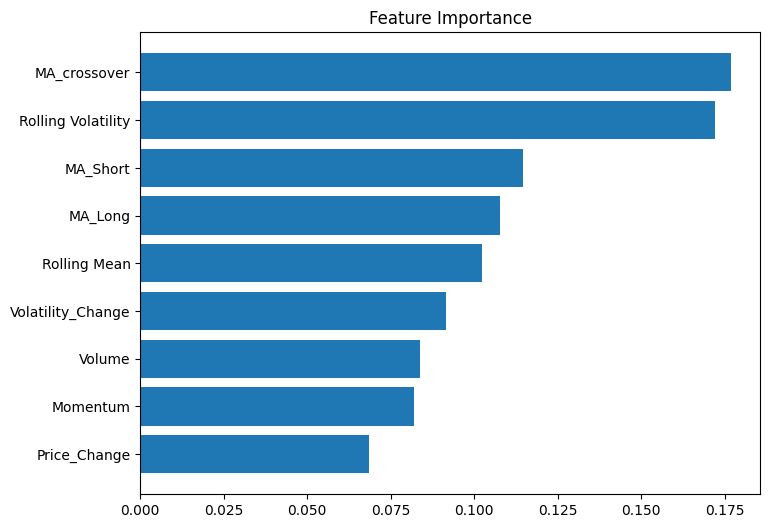

In [17]:

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/day_7.csv")
print(df.shape)
print(df.columns)

feature_importance = model.feature_importances_

features = x_train.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)
plt.figure(figsize=(8,6))

plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

# Feature Importance Analysis


+ Feature importance was analyzed using the XGBoost classifier to determine which technical indicators contributed most to the model's predictions. 
+ The results indicate that moving-average-based indicators such as MA_crossover, MA_Short, and MA_Long had the highest importance values. 
+ In addition, Rolling Volatility and Rolling Mean also played significant roles in influencing model decisions.


+ These results suggest that the model primarily relies on trend detection and volatility patterns when generating Buy, Hold, and Sell signals. 
+ Indicators such as Volume, Momentum, and Price Change contributed less to the predictive power of the model. 
+ This behavior aligns with common financial trading strategies, where moving-average crossovers and volatility signals are frequently used to identify market trends and potential entry or exit points.

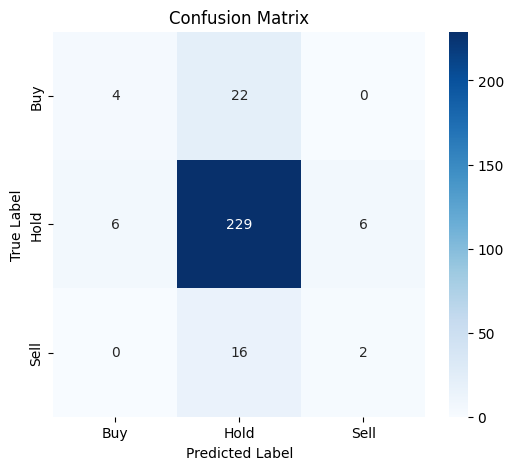

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# Confusion Matrix Analysis


+ The confusion matrix provides insight into the model’s classification performance across the three trading signals: Buy, Hold, and Sell. 
+ The model demonstrates strong performance in predicting the Hold class, correctly identifying 229 instances. 
+ This result is expected since Hold signals represent the majority of observations in the dataset.


+ However, the model shows weaker performance in identifying Buy and Sell signals. 
+ Out of 26 actual Buy signals, only 4 were correctly classified, while the remaining were mostly predicted as Hold. 
+ Similarly, only 2 out of 18 Sell signals were correctly identified, with most being classified as Hold.


+ These results indicate that while the model is effective at recognizing stable market conditions, it struggles to capture turning points associated with Buy and Sell signals. 
+ This challenge is common in financial machine learning due to the rarity and unpredictability of such events.

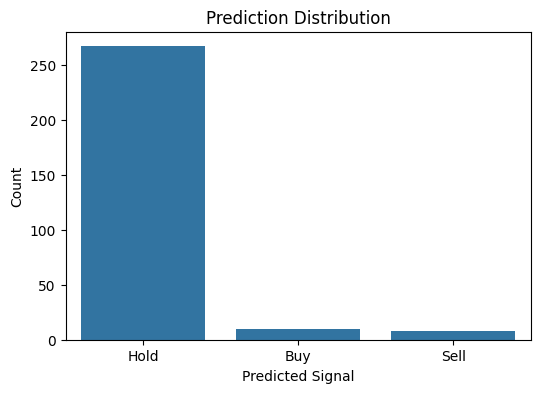

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x=y_pred)

plt.title("Prediction Distribution")

plt.xlabel("Predicted Signal")
plt.ylabel("Count")

plt.show()

# Prediction Distribution Analysis


+ The prediction distribution analysis shows that the model predominantly generates Hold signals, while Buy and Sell signals occur much less frequently. 
+ This pattern reflects the natural behavior of financial markets, where stable periods occur more often than strong upward or downward movements.


+ The dominance of Hold predictions indicates that the model is conservative and avoids generating excessive trading signals. 
+ Such behavior can help reduce unnecessary trading activity and potential transaction costs in real-world applications. 
+ However, the limited number of Buy and Sell predictions also suggests that the model may struggle to identify rare market turning points effectively.


+ This observation highlights a common challenge in financial machine learning: class imbalance, where profitable trading opportunities are significantly less frequent than neutral market conditions.

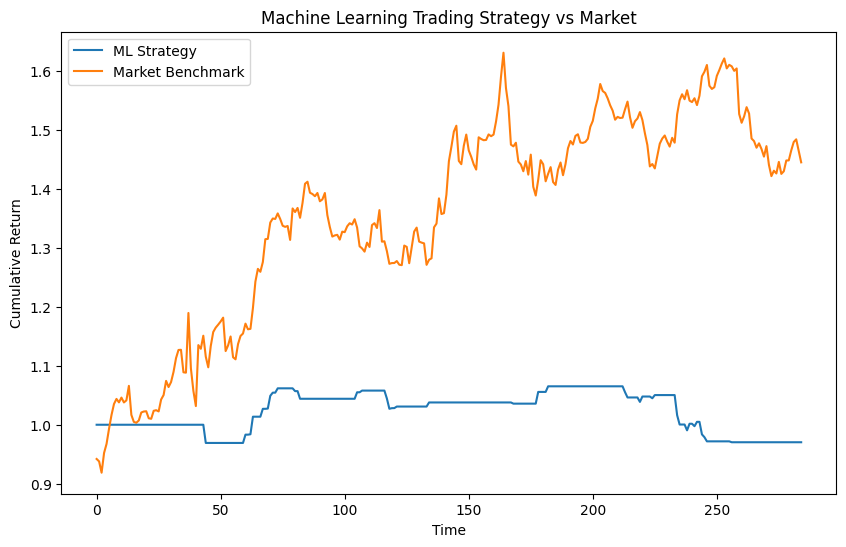

In [21]:
df_backtest = pd.read_csv("../data/day_9_backtesting_results.csv")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(df_backtest["Cumulative_Model_Return"], label="ML Strategy")

plt.plot(df_backtest["Cumulative_Market_Return"], label="Market Benchmark")

plt.title("Machine Learning Trading Strategy vs Market")

plt.xlabel("Time")

plt.ylabel("Cumulative Return")

plt.legend()

plt.show()

# Strategy Performance Comparison


* The final backtesting analysis compares the cumulative returns of the machine learning trading strategy with the market benchmark. 
* The results indicate that the market benchmark outperformed the machine learning strategy over the evaluation period.


* Although the classifier achieved an overall prediction accuracy of approximately 82%, the trading strategy derived from these predictions did not generate higher cumulative returns than the market. 
* This highlights a well-known challenge in financial machine learning: strong classification performance does not necessarily translate into profitable trading outcomes.


* One possible explanation is that the model tends to generate a large number of Hold predictions while producing relatively few Buy and Sell signals. 
* As a result, the strategy participates in fewer profitable market movements compared to a passive market investment.


* These findings emphasize the importance of evaluating machine learning models not only through prediction accuracy but also through practical trading performance metrics such as cumulative return, Sharpe ratio, and drawdown.

In [22]:
strategy_return = df_backtest["Cumulative_Model_Return"].iloc[-1] - 1
market_return = df_backtest["Cumulative_Market_Return"].iloc[-1] - 1

sharpe_ratio = df_backtest["Model_Strategy_Return"].mean() / df_backtest["Model_Strategy_Return"].std()

rolling_max = df_backtest["Cumulative_Model_Return"].cummax()
drawdown = (df_backtest["Cumulative_Model_Return"] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print("Strategy Return:", strategy_return)
print("Market Return:", market_return)
print("Sharpe Ratio:", sharpe_ratio)
print("Max Drawdown:", max_drawdown)

Strategy Return: -0.0297113309126128
Market Return: 0.4455067567795985
Sharpe Ratio: -0.019792872896705376
Max Drawdown: -0.08914549829710325


# Trading Performance Metrics


- The final evaluation of the trading strategy was conducted using several performance metrics derived from the backtesting results. 
- The machine learning strategy produced a total return of approximately -2.97%, indicating a small overall loss during the evaluation period. 
- In contrast, the market benchmark achieved a significantly higher return of 44.55%, suggesting that a passive buy-and-hold approach outperformed the model-based strategy.


- The strategy also exhibited a Sharpe ratio of -0.019, indicating poor risk-adjusted performance. 
- This implies that the returns generated by the strategy were insufficient relative to the volatility experienced. 
- Additionally, the maximum drawdown was approximately -8.91%, representing the largest decline from a previous peak during the backtesting period.


- These results highlight a key challenge in financial machine learning: even models with reasonable classification accuracy may fail to generate profitable trading strategies when evaluated under realistic market conditions.

# Project Conclusion


+ This project aimed to develop a machine learning-based trading strategy capable of generating Buy, Hold, and Sell signals using technical indicators derived from historical market data. 
+ The dataset was processed through several stages including feature engineering, target construction, model training, and performance evaluation.


+ Multiple technical indicators such as moving averages, rolling volatility, momentum, and price changes were used as input features. 
+ A classification model based on the gradient boosting algorithm implemented in XGBoost was trained to predict trading signals. 
+ The model achieved an overall classification accuracy of approximately 82%, demonstrating reasonable predictive capability for identifying market conditions.


+ However, when the predictions were applied within a simulated trading environment through backtesting, the resulting strategy did not outperform the market benchmark. 
+ The strategy produced a total return of approximately -2.97%, compared to a 44.55% market return over the same period. 
+ This outcome highlights an important insight: high prediction accuracy alone does not guarantee profitable trading performance.


+ Despite this limitation, the project successfully demonstrated the complete pipeline of a quantitative trading system, including data preprocessing, feature engineering, machine learning modeling, strategy backtesting, and performance evaluation. 
+ The results provide a valuable foundation for future improvements such as enhanced feature engineering, improved signal filtering, alternative modeling techniques, and more sophisticated portfolio management approaches.


+ Overall, this project illustrates both the potential and the challenges of applying machine learning techniques to financial market prediction and algorithmic trading.